In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error

In [35]:
insta = pd.read_csv('https://raw.githubusercontent.com/amankharwal/Website-data/master/instagram_reach.csv')
insta

,Unnamed: 0,S.No,USERNAME,Caption,Followers,Hashtags,Time since posted,Likes
0,0,1,mikequindazzi,Who are #DataScientist and what do they do? >>...,1600,#MachineLearning #AI #DataAnalytics #DataScien...,11 hours,139
1,1,2,drgorillapaints,We all know where it’s going. We just have to ...,880,#deck .#mac #macintosh#sayhello #apple #steve...,2 hours,23
2,2,3,aitrading_official,Alexander Barinov: 4 years as CFO in multinati...,255,#whoiswho #aitrading #ai #aitradingteam#instat...,2 hours,25
3,3,4,opensourcedworkplace,sfad,340,#iot #cre#workplace #CDO #bigdata #technology#...,3 hours,49
4,4,5,crea.vision,Ever missed a call while your phone was chargi...,304,#instamachinelearning #instabigdata#instamarke...,3 hours,30
...,...,...,...,...,...,...,...,...
95,8,19,michaelgarza__,"328 S. Wetherly Drive, Beverly Hills, CA 90212...",614,#beverlyhills #realestate#losangelesrealestate...,3 hours,31
96,9,21,dvlp_search,Credit @tristankappel To find more dvlp follow...,450,#workspace #work #developer#development #devel...,3 hours,42
97,10,22,ecom.space,We are coming up with the Best 21 Books that w...,182,#books #book #motivation #inspiration #life#bo...,3 hours,10
98,11,24,lb3enterprises,We’re only paid to move dirt once. It’s not ju...,2039,#heavyequipment #underconstruction#dozer #real...,3 hours,222


In [36]:
insta.drop(['Unnamed: 0', 'S.No'], axis=1, inplace=True)
insta

,USERNAME,Caption,Followers,Hashtags,Time since posted,Likes
0,mikequindazzi,Who are #DataScientist and what do they do? >>...,1600,#MachineLearning #AI #DataAnalytics #DataScien...,11 hours,139
1,drgorillapaints,We all know where it’s going. We just have to ...,880,#deck .#mac #macintosh#sayhello #apple #steve...,2 hours,23
2,aitrading_official,Alexander Barinov: 4 years as CFO in multinati...,255,#whoiswho #aitrading #ai #aitradingteam#instat...,2 hours,25
3,opensourcedworkplace,sfad,340,#iot #cre#workplace #CDO #bigdata #technology#...,3 hours,49
4,crea.vision,Ever missed a call while your phone was chargi...,304,#instamachinelearning #instabigdata#instamarke...,3 hours,30
...,...,...,...,...,...,...
95,michaelgarza__,"328 S. Wetherly Drive, Beverly Hills, CA 90212...",614,#beverlyhills #realestate#losangelesrealestate...,3 hours,31
96,dvlp_search,Credit @tristankappel To find more dvlp follow...,450,#workspace #work #developer#development #devel...,3 hours,42
97,ecom.space,We are coming up with the Best 21 Books that w...,182,#books #book #motivation #inspiration #life#bo...,3 hours,10
98,lb3enterprises,We’re only paid to move dirt once. It’s not ju...,2039,#heavyequipment #underconstruction#dozer #real...,3 hours,222


In [37]:
insta.rename(columns = {'USERNAME':'Username', 'Time since posted':'Hours Since Posted'}, inplace=True)
insta

,Username,Caption,Followers,Hashtags,Hours Since Posted,Likes
0,mikequindazzi,Who are #DataScientist and what do they do? >>...,1600,#MachineLearning #AI #DataAnalytics #DataScien...,11 hours,139
1,drgorillapaints,We all know where it’s going. We just have to ...,880,#deck .#mac #macintosh#sayhello #apple #steve...,2 hours,23
2,aitrading_official,Alexander Barinov: 4 years as CFO in multinati...,255,#whoiswho #aitrading #ai #aitradingteam#instat...,2 hours,25
3,opensourcedworkplace,sfad,340,#iot #cre#workplace #CDO #bigdata #technology#...,3 hours,49
4,crea.vision,Ever missed a call while your phone was chargi...,304,#instamachinelearning #instabigdata#instamarke...,3 hours,30
...,...,...,...,...,...,...
95,michaelgarza__,"328 S. Wetherly Drive, Beverly Hills, CA 90212...",614,#beverlyhills #realestate#losangelesrealestate...,3 hours,31
96,dvlp_search,Credit @tristankappel To find more dvlp follow...,450,#workspace #work #developer#development #devel...,3 hours,42
97,ecom.space,We are coming up with the Best 21 Books that w...,182,#books #book #motivation #inspiration #life#bo...,3 hours,10
98,lb3enterprises,We’re only paid to move dirt once. It’s not ju...,2039,#heavyequipment #underconstruction#dozer #real...,3 hours,222


In [38]:
insta['Hours Since Posted'] = insta['Hours Since Posted'].str.replace(' hours','')
insta['Hours Since Posted'] = insta['Hours Since Posted'].astype('int')
insta

,Username,Caption,Followers,Hashtags,Hours Since Posted,Likes
0,mikequindazzi,Who are #DataScientist and what do they do? >>...,1600,#MachineLearning #AI #DataAnalytics #DataScien...,11,139
1,drgorillapaints,We all know where it’s going. We just have to ...,880,#deck .#mac #macintosh#sayhello #apple #steve...,2,23
2,aitrading_official,Alexander Barinov: 4 years as CFO in multinati...,255,#whoiswho #aitrading #ai #aitradingteam#instat...,2,25
3,opensourcedworkplace,sfad,340,#iot #cre#workplace #CDO #bigdata #technology#...,3,49
4,crea.vision,Ever missed a call while your phone was chargi...,304,#instamachinelearning #instabigdata#instamarke...,3,30
...,...,...,...,...,...,...
95,michaelgarza__,"328 S. Wetherly Drive, Beverly Hills, CA 90212...",614,#beverlyhills #realestate#losangelesrealestate...,3,31
96,dvlp_search,Credit @tristankappel To find more dvlp follow...,450,#workspace #work #developer#development #devel...,3,42
97,ecom.space,We are coming up with the Best 21 Books that w...,182,#books #book #motivation #inspiration #life#bo...,3,10
98,lb3enterprises,We’re only paid to move dirt once. It’s not ju...,2039,#heavyequipment #underconstruction#dozer #real...,3,222


In [39]:
insta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Username            100 non-null    object
 1   Caption             94 non-null     object
 2   Followers           100 non-null    int64 
 3   Hashtags            100 non-null    object
 4   Hours Since Posted  100 non-null    int64 
 5   Likes               100 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 4.8+ KB


In [40]:
insta.Caption.isnull().sum()

np.int64(6)

In [41]:
insta = insta.dropna()

In [42]:
display(insta.head())

,Username,Caption,Followers,Hashtags,Hours Since Posted,Likes
0,mikequindazzi,Who are #DataScientist and what do they do? >>...,1600,#MachineLearning #AI #DataAnalytics #DataScien...,11,139
1,drgorillapaints,We all know where it’s going. We just have to ...,880,#deck .#mac #macintosh#sayhello #apple #steve...,2,23
2,aitrading_official,Alexander Barinov: 4 years as CFO in multinati...,255,#whoiswho #aitrading #ai #aitradingteam#instat...,2,25
3,opensourcedworkplace,sfad,340,#iot #cre#workplace #CDO #bigdata #technology#...,3,49
4,crea.vision,Ever missed a call while your phone was chargi...,304,#instamachinelearning #instabigdata#instamarke...,3,30


In [43]:
insta.describe()

,Followers,Hours Since Posted,Likes
count,94.000000,94.000000,94.000000
mean,942.627660,3.521277,47.882979
std,1023.894946,3.488009,56.501757
min,11.000000,2.000000,8.000000
25%,231.000000,2.000000,19.000000
50%,593.500000,2.000000,29.500000
75%,1177.000000,3.000000,46.000000
max,4496.000000,24.000000,349.000000


<Axes: >

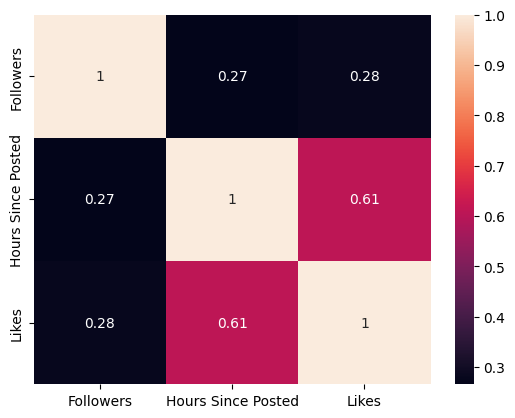

In [44]:
sns.heatmap(insta.corr(numeric_only=True), annot=True)

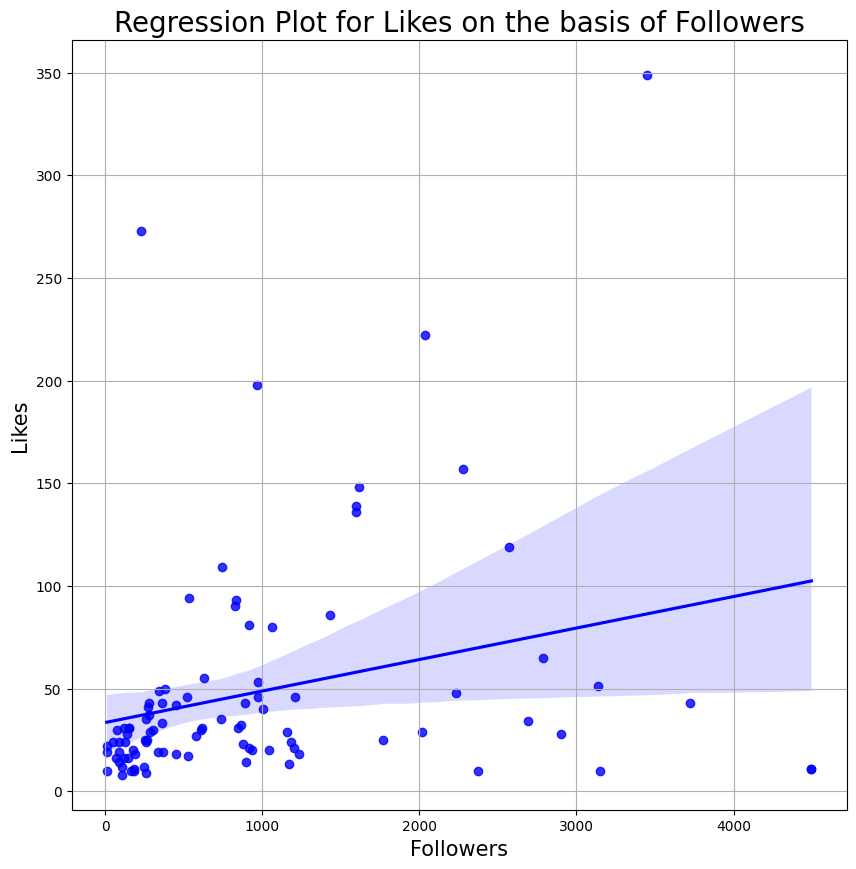

In [45]:
plt.figure(figsize=(10,10))
sns.regplot(x='Followers', y='Likes', data=insta, color='blue')
plt.xlabel('Followers', size=15)
plt.ylabel('Likes', size=15)
plt.title('Regression Plot for Likes on the basis of Followers', size=20)
plt.grid()
plt.show()

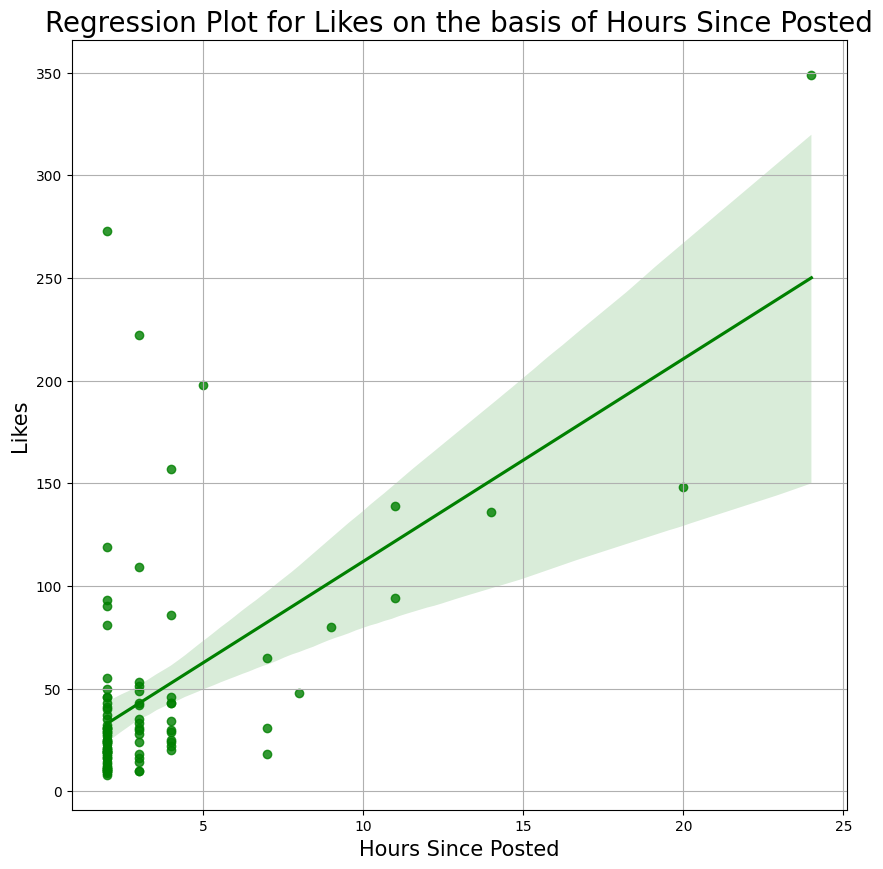

In [46]:
plt.figure(figsize=(10,10))
sns.regplot(x='Hours Since Posted', y='Likes', data=insta, color='green')
plt.xlabel('Hours Since Posted', size=15)
plt.ylabel('Likes', size=15)
plt.title('Regression Plot for Likes on the basis of Hours Since Posted', size=20)
plt.grid()
plt.show()

In [47]:
from wordcloud import WordCloud, STOPWORDS
stopwords = set(STOPWORDS)
stopwords.add('will')
stopwords.add('new')

def wordcloud(column):
    words = ''
    data = insta[column]
    for word in data:
        words = words + str(word)

    wc = WordCloud(width=800, height=800, stopwords=stopwords, min_font_size=15).generate(words)

    plt.figure(figsize = (8,8), facecolor = None)
    plt.imshow(wc)
    plt.axis("off")
    plt.tight_layout(pad = 0)
    plt.title('Word Cloud of column ' + str(column), size=20)
    plt.show()

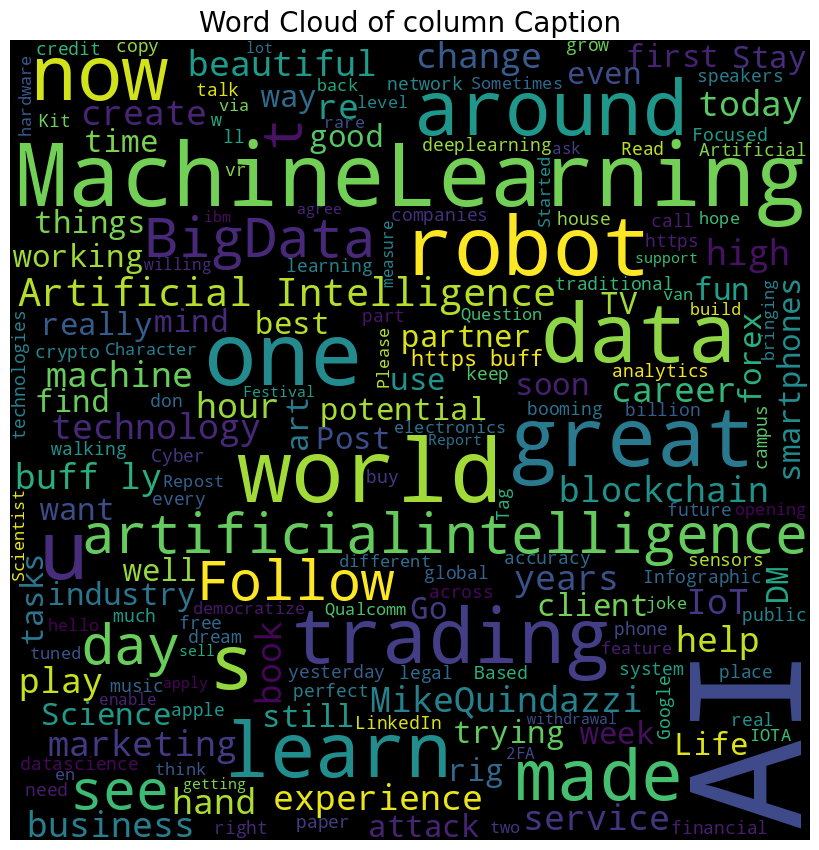

In [48]:
wordcloud('Caption')

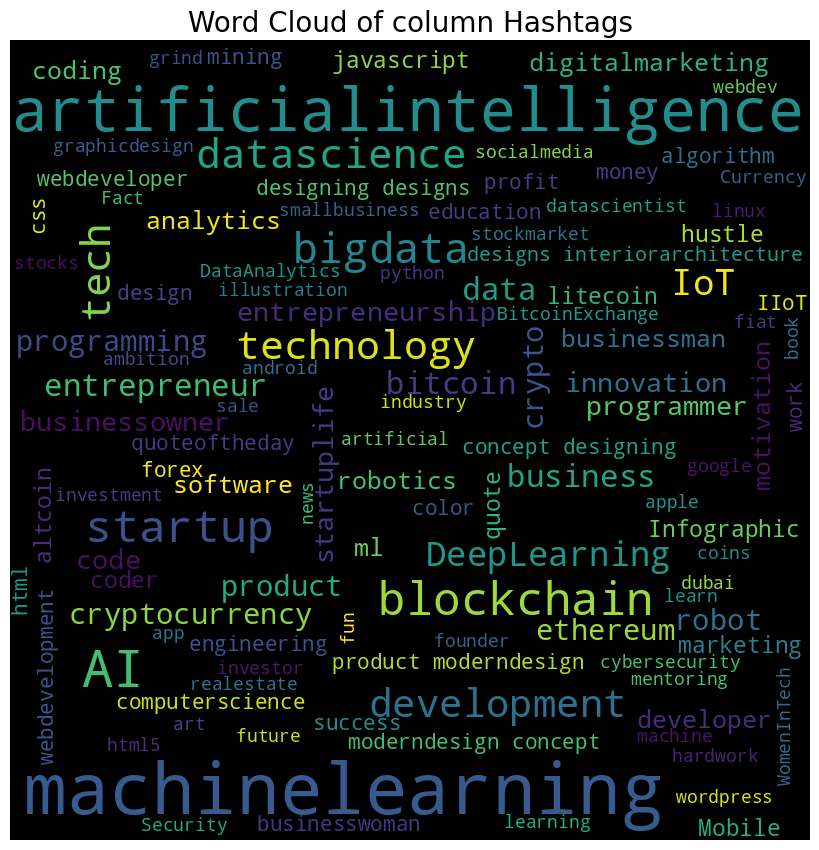

In [49]:
wordcloud('Hashtags')

In [50]:
insta = pd.get_dummies(insta)

In [51]:
insta.columns

Index(['Followers', 'Hours Since Posted', 'Likes', 'Username__ehab.othman_',
       'Username__linda_smith567', 'Username_ah_studio_',
       'Username_aitrading_official', 'Username_ale_borba',
       'Username_alpha_mentor_', 'Username_amjstaffing',
       ...
       'Hashtags_#whoiswho #aitrading #ai #aitradingteam#instateam #instapeople #ai #trading#artificialintelligence #crypto#cryptocurrency #blockchain #tradingforex#forex #fiatmoney #coins #machinelearning#userexperience #instamachinelearning#instabigdata #instamarketing#artificialintelligence #deeplearning#datascience #industry #marketing#bigdata #datascience #machinelearning#ml',
       'Hashtags_#workspace #work #developer#development #developerlife #apple #imac#macbook #macbookpro #blackandwhite#coder #code #coding #html #css #php#wordpress #javascript #dvlp_search #linux#ubuntu #webdeveloper #webdev#webdevelopment #dev #coder #coding#code',
       'Hashtags_#worldcode #coding#python #codeaholics #rstudio #codinglife#worldo

In [52]:
insta

,Followers,Hours Since Posted,Likes,Username__ehab.othman_,Username__linda_smith567,Username_ah_studio_,Username_aitrading_official,Username_ale_borba,Username_alpha_mentor_,Username_amjstaffing,...,Hashtags_#whoiswho #aitrading #ai #aitradingteam#instateam #instapeople #ai #trading#artificialintelligence #crypto#cryptocurrency #blockchain #tradingforex#forex #fiatmoney #coins #machinelearning#userexperience #instamachinelearning#instabigdata #instamarketing#artificialintelligence #deeplearning#datascience #industry #marketing#bigdata #datascience #machinelearning#ml,Hashtags_#workspace #work #developer#development #developerlife #apple #imac#macbook #macbookpro #blackandwhite#coder #code #coding #html #css #php#wordpress #javascript #dvlp_search #linux#ubuntu #webdeveloper #webdev#webdevelopment #dev #coder #coding#code,Hashtags_#worldcode #coding#python #codeaholics #rstudio #codinglife#worldofprogrammers #datascience#machinelearning #dataviz #data #statistics#macbookpro #peoplewhocode#codeismylife #datavisualization#artificialintelligence #digitalnomads#digitalnomad #travel,Hashtags_#youtube #applemusic #itunes#soundcloud #spinrilla #spotify #bigdata#blockchain #dontbandwagonlater,Hashtags_#любовь #gm #sme #smenigeria #profits#businessowners #businessplan#entrepreneurship #entrepreneur#blockchain #crypto #cointelegraph#bitcoinprice #mining #cryptocurrencies#bch #bitcoins #litecoin #investment#investor #stockmarket #stocks #getrich#makemoney #makemoneyonline#mentorship #mentoring #xrp #bitfinex#altcoins,Hashtags_.#Tech #virtualreality #IoT #Machinelearning,Hashtags_[#Infographic] #Wearable #Sensors #MachineLearning#IoT #BigData #DigitalTransformation#futureofwork #marketing #analytics#bigdata #Cloud #Blogging#ContentMarketing #DigitalMarketing ht: #BigData #MachineLearning #AI #IoT#infograp,Hashtags_thebeautymindset#businessman#quoteoftheday #businessowner#businesswoman #success #grind#motivation #motivational #lifestyle#happiness #entrepreneurs#entrepreneurlife #business #working #founder#startup #money #magazine #moneymaker#startuplife #successful #passion #inspiredaily#hardwork #hardworkpaysoff #desire,Hashtags_ #datascience #data #tech #technology#future #machinelearning #ai#visualizations #dataisbeautiful,Hashtags_ #deck .#mac #macintosh#sayhello #apple #stevejobs #ai #evolution#artificialintelligence #machinelearning#terminator #illbeback #technology#computerevolution #computerscience#sciencefiction#computersciencetosciencefiction#tomorrowstechnology #vr #ar #robot#robots #t2 #businessdeck #businessslides#illustration #sketches #drawing
0,1600,11,139,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,880,2,23,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,255,2,25,False,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3,340,3,49,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,304,3,30,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,614,3,31,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
96,450,3,42,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
97,182,3,10,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
98,2039,3,222,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [53]:
target = insta['Likes']
features = insta.drop('Likes', axis=1)

print(f"Number of features after preprocessing: {features.shape[1]}")

Number of features after preprocessing: 278


In [54]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(features, target, test_size = 0.3, random_state = 10)

In [55]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
xtrain = sc.fit_transform(xtrain)
xtest = sc.transform(xtest)

#### Random Forest Regressor

In [56]:
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rfr.fit(xtrain, ytrain)

pred = rfr.predict(xtest)

print("R2:", r2_score(ytest, pred))
print("MAE:", mean_absolute_error(ytest, pred))
print("RMSE:", root_mean_squared_error(ytest, pred))

R2: 0.09087362215854689
MAE: 19.086551724137927
RMSE: 48.339885196039546


#### Gradient Boosting Regressor

In [57]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor()
gbr.fit(xtrain, ytrain)

GradientBoostingRegressor()

In [58]:
ypred = gbr.predict(xtest)
ypred

array([ 19.96680013,  20.90030196,  33.25220788,  31.98712833,
        68.21921397,  32.31870605,  22.21990052,  22.21990052,
        24.40315846,  50.54890628, 135.77063968,  23.15340235,
        33.24219745,  19.96680013,  23.15340235,  55.58789666,
        31.98712833,  32.87063164,  55.58789666,  32.31870605,
        68.21921397,  32.31870605,  20.90030196,  19.96680013,
        19.96680013,  24.40315846,  66.16477319,  19.96680013,
        19.96680013])

In [59]:
print('R2_score : ',r2_score(ytest,ypred))
print('mae_score : ',mean_absolute_error(ytest, ypred))
print('rmse_score : ',root_mean_squared_error(ytest, ypred))

R2_score :  0.047854295060837604
mae_score :  20.90882450763653
rmse_score :  49.47037376350787


#### Linear Regression

In [60]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(xtrain, ytrain)

LinearRegression()

In [61]:
prediction = lr.predict(xtest)
prediction

array([44.85523513, 47.17863223, 47.87297593, 48.99492982, 60.72139298,
       45.49244928, 44.25317762, 44.3234909 , 44.38062045, 47.11404943,
       76.66606911, 46.77872542, 47.72929068, 44.94312673, 46.42715899,
       59.14067996, 48.12919749, 57.69180434, 62.74863043, 45.0617804 ,
       68.68475946, 45.3298498 , 47.51701492, 45.02662376, 44.71021397,
       44.49927412, 56.65640616, 44.64868985, 44.98267796])

In [62]:
print('R2_score : ',r2_score(ytest, prediction))
print('mae_score : ',mean_absolute_error(ytest, prediction))
print('rmse_score : ',root_mean_squared_error(ytest, prediction))

R2_score :  -0.007893193080182437
mae_score :  32.509322999875394
rmse_score :  50.89800280736164


### Model Comparison Visualizations

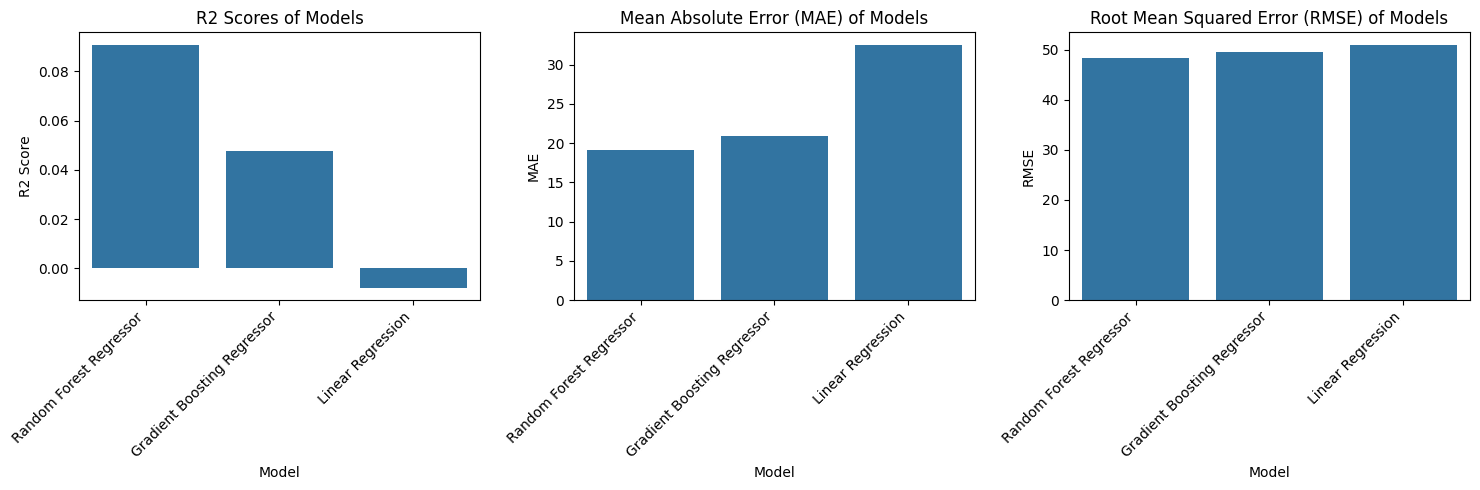

In [63]:
model_names = ['Random Forest Regressor', 'Gradient Boosting Regressor', 'Linear Regression']
r2_scores = [
    r2_score(ytest, pred), # from Random Forest
    r2_score(ytest, ypred), # from Gradient Boosting
    r2_score(ytest, prediction) # from Linear Regression
]
mae_scores = [
    mean_absolute_error(ytest, pred), # from Random Forest
    mean_absolute_error(ytest, ypred), # from Gradient Boosting
    mean_absolute_error(ytest, prediction) # from Linear Regression
]
rmse_scores = [
    root_mean_squared_error(ytest, pred), # from Random Forest
    root_mean_squared_error(ytest, ypred), # from Gradient Boosting
    root_mean_squared_error(ytest, prediction) # from Linear Regression
]

metrics_df = pd.DataFrame({
    'Model': model_names,
    'R2 Score': r2_scores,
    'MAE': mae_scores,
    'RMSE': rmse_scores
})

metrics_df_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.barplot(x='Model', y='R2 Score', data=metrics_df)
plt.title('R2 Scores of Models')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 3, 2)
sns.barplot(x='Model', y='MAE', data=metrics_df)
plt.title('Mean Absolute Error (MAE) of Models')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 3, 3)
sns.barplot(x='Model', y='RMSE', data=metrics_df)
plt.title('Root Mean Squared Error (RMSE) of Models')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


/tmp/ipykernel_909/4174397018.py:8: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


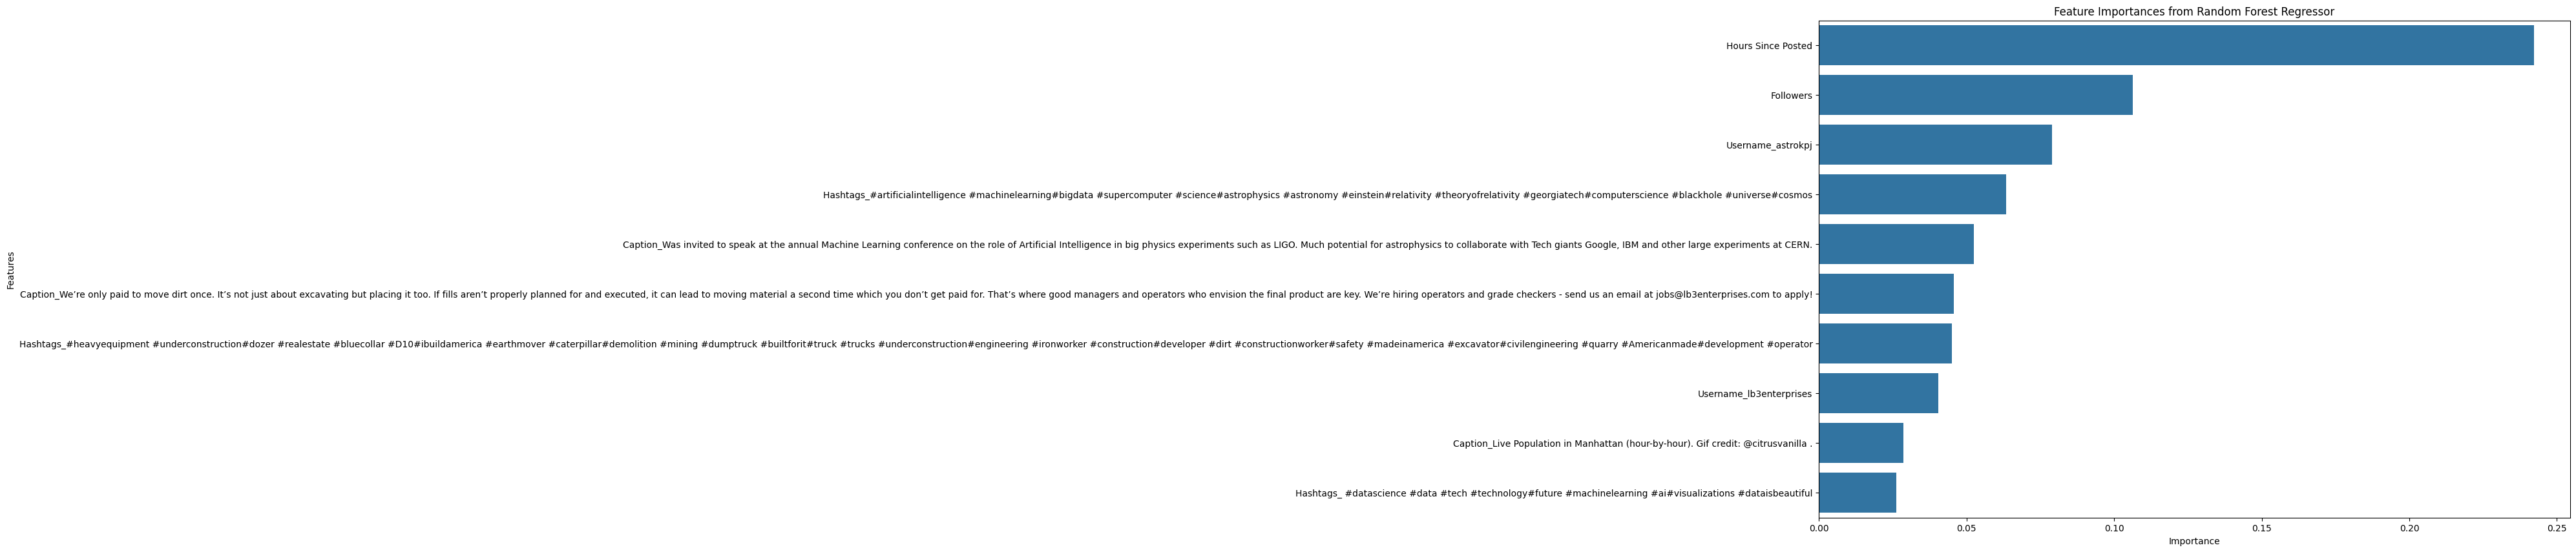

In [72]:
feature_importances = pd.Series(rfr.feature_importances_, index=features.columns).sort_values(ascending=False).nlargest(10)

plt.figure(figsize=(15, 10)) # Further increased figure size for better readability
sns.barplot(x=feature_importances.values, y=feature_importances.index)
plt.title('Feature Importances from Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

### We see that posts regarding artificial intelligence, machine learning, big data, trading, etc can help with better reach on Instagram. Although more followers give more number of likes, but as the time of the post increases, it gets a better reach. So, a clever use of hashtags according to the followers can account for a good reach of Instagram posts.